In [ ]:
# import warnings
# warnings.filterwarnings('ignore')
# !pip install --upgrade scikit-learn xgboost lightgbm numpy pandas matplotlib seaborn scipy statsmodels


In [8]:
import pandas as pd
# flood_data = pd.read_csv('dataset\flood_dataset.csv')
flood_data = pd.read_csv(r'dataset\flood_dataset.csv')


In [9]:
flood_data.head()

,Latitude,Longitude,Rainfall,Temperature,Humidity,River_Discharge,Water_Level,Elevation,Land_Cover,Soil_Type,Population_Density,Infrastructure,Historical_Floods,Flood_Occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465434,Water Body,Clay,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0


In [10]:
flood_data.describe()

,Latitude,Longitude,Rainfall,Temperature,Humidity,River_Discharge,Water_Level,Elevation,Population_Density,Infrastructure,Historical_Floods,Flood_Occurred
count,40000.000000,39997.000000,39997.000000,39999.000000,39998.000000,39998.000000,39999.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,22.330627,82.631649,150.022325,29.961644,59.749439,2515.806066,5.017925,4417.138177,5021.468442,0.502000,0.498700,0.505700
std,8.340961,8.389172,86.026911,8.669485,23.141308,1441.635507,2.876494,2530.150533,2882.483418,0.500002,0.500005,0.499974
min,8.000337,68.004575,0.014437,15.000166,20.001339,0.042161,0.002701,1.150340,2.289000,0.000000,0.000000,0.000000
25%,15.143537,75.365026,76.128784,22.406107,39.543126,1284.900687,2.538601,2229.681903,2491.766601,0.000000,0.000000,0.000000
50%,22.283330,82.671861,150.621482,30.005920,59.497375,2530.782359,5.043840,4417.199760,5074.392880,1.000000,0.000000,1.000000
75%,29.460184,89.938032,223.425208,37.413753,80.034414,3767.907792,7.524884,6616.729065,7474.228752,1.000000,1.000000,1.000000
max,36.991813,96.997820,299.970293,44.993681,99.997772,4999.698480,9.996899,8846.894877,9999.169530,1.000000,1.000000,1.000000


In [11]:
print(flood_data.isnull().sum())


Latitude              0
Longitude             3
Rainfall              3
Temperature           1
Humidity              2
River_Discharge       2
Water_Level           1
Elevation             0
Land_Cover            0
Soil_Type             0
Population_Density    0
Infrastructure        0
Historical_Floods     0
Flood_Occurred        0
dtype: int64


In [12]:
for col in flood_data.columns:
  if pd.api.types.is_numeric_dtype(flood_data[col]):
    mean_value = flood_data[col].mean()
    flood_data[col].fillna(value=mean_value, inplace=True)
print(flood_data.isnull().sum())

Latitude              0
Longitude             0
Rainfall              0
Temperature           0
Humidity              0
River_Discharge       0
Water_Level           0
Elevation             0
Land_Cover            0
Soil_Type             0
Population_Density    0
Infrastructure        0
Historical_Floods     0
Flood_Occurred        0
dtype: int64


C:\Users\Sachin Tripathi\AppData\Local\Temp\ipykernel_21580\1370474508.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  flood_data[col].fillna(value=mean_value, inplace=True)


In [13]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

categorical_cols = flood_data.select_dtypes(include=['object']).columns

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    flood_data[col] = le.fit_transform(flood_data[col].astype(str))
    label_encoders[col] = le

for col in categorical_cols:
    print(f"\nColumn '{col}':")
    unique_values = flood_data[col].unique()
    for value in unique_values:
        original_value = label_encoders[col].inverse_transform([value])[0]
        print(f"  Encoded {value} represents '{original_value}'")



Column 'Land_Cover':
  Encoded 4 represents 'Water Body'
  Encoded 2 represents 'Forest'
  Encoded 0 represents 'Agricultural'
  Encoded 1 represents 'Desert'
  Encoded 3 represents 'Urban'

Column 'Soil_Type':
  Encoded 0 represents 'Clay'
  Encoded 2 represents 'Peat'
  Encoded 1 represents 'Loam'
  Encoded 3 represents 'Sandy'
  Encoded 4 represents 'Silt'


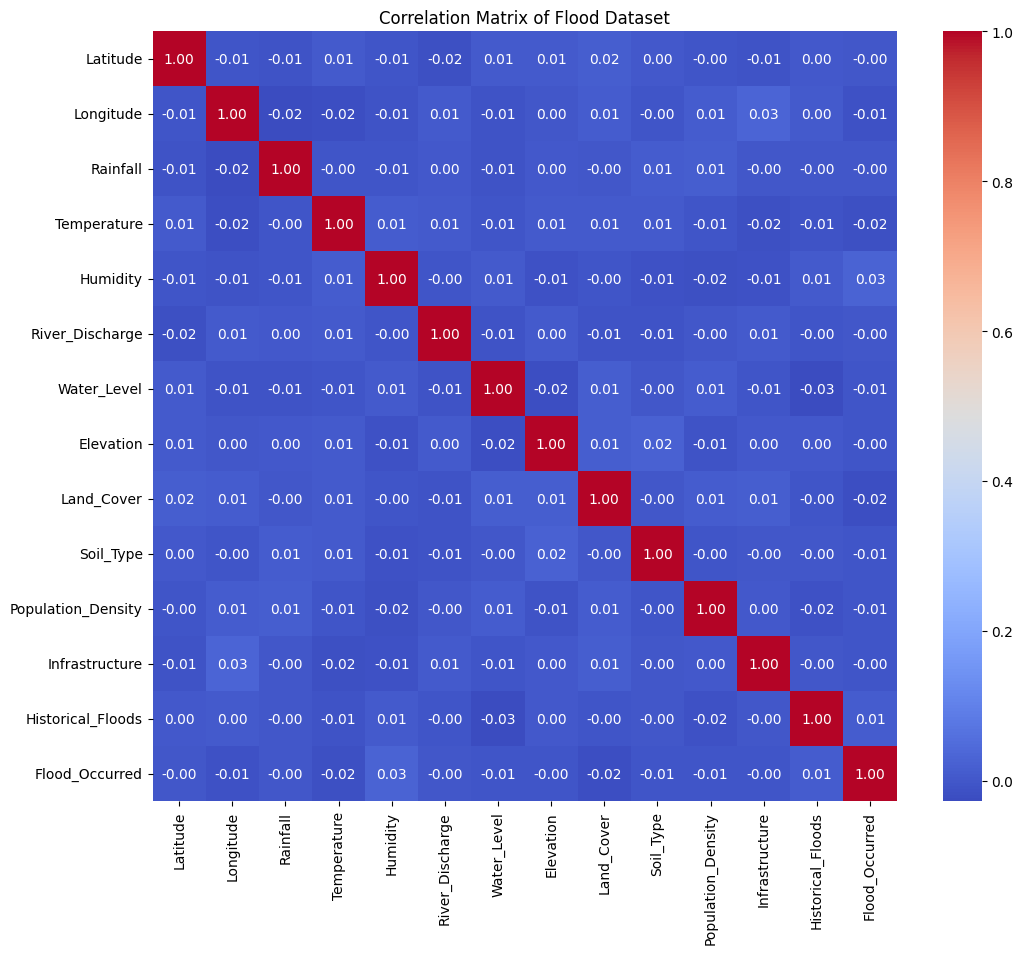

In [14]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
correlation_matrix = flood_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Flood Dataset')
plt.show()

In [15]:
X = flood_data.drop(['Flood_Occurred'], axis=1)
y = flood_data['Flood_Occurred']

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter = 2000,random_state=42)
y_train = y_train.astype(int)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy_lr * 100:.2f}%")


Logistic Regression Accuracy: 51.92%


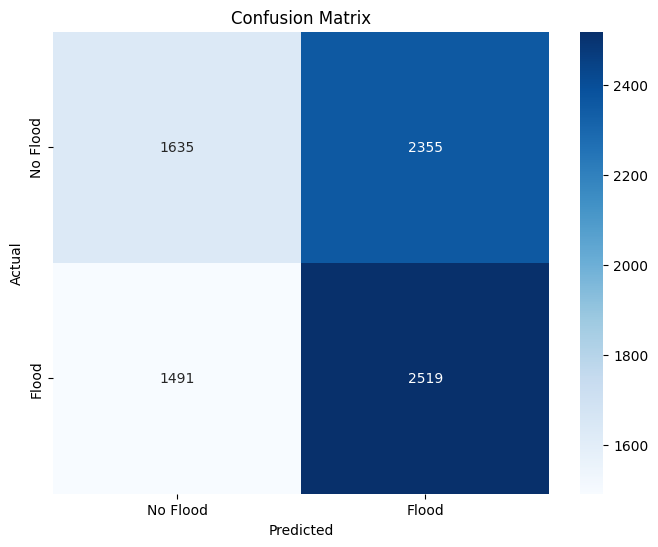

In [18]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Flood', 'Flood'],
            yticklabels=['No Flood', 'Flood'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42,max_depth=40)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy_dt * 100:.2f}%")


Decision Tree Accuracy: 99.48%


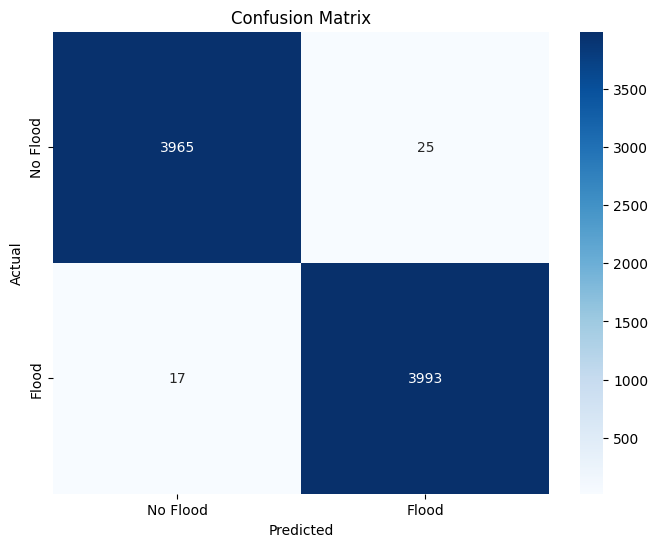

In [20]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Flood', 'Flood'],
            yticklabels=['No Flood', 'Flood'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42,max_depth=20,n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_rf * 100:.2f}%")

Accuracy: 99.40%


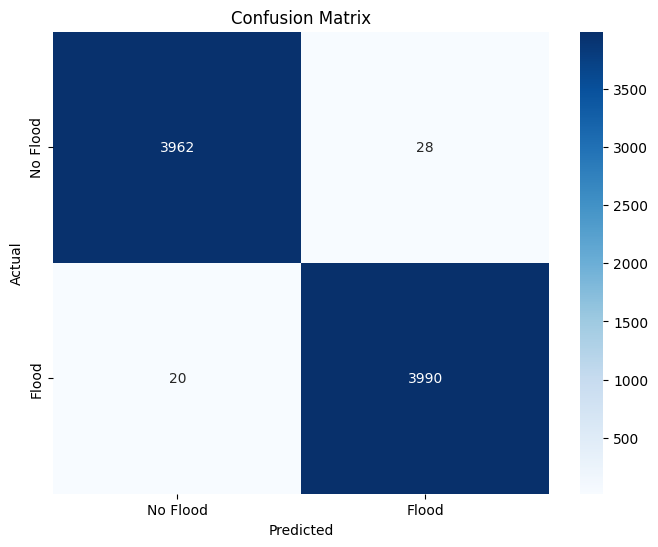

In [22]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Flood', 'Flood'],
            yticklabels=['No Flood', 'Flood'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred)
print(f"SVM Accuracy: {accuracy_svm * 100:.2f}%")


SVM Accuracy: 50.12%


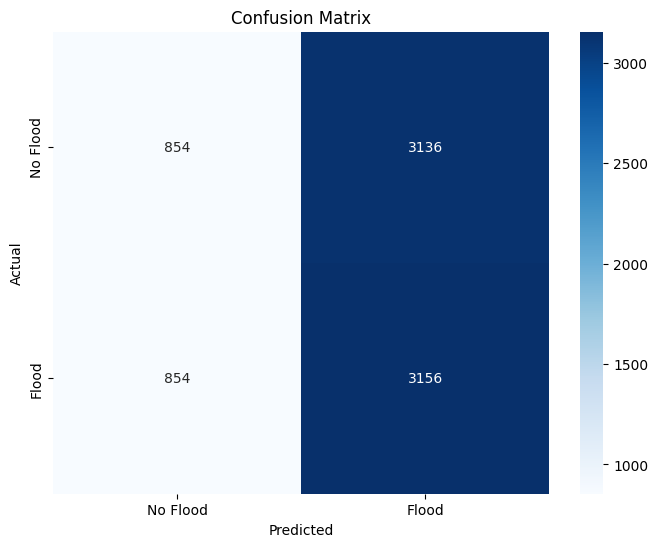

In [24]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Flood', 'Flood'],
            yticklabels=['No Flood', 'Flood'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy_knn * 100:.2f}%")


KNN Accuracy: 77.56%


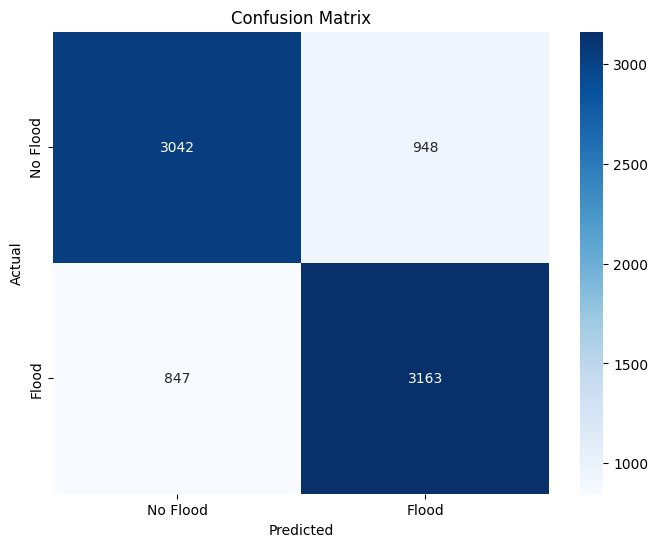

In [26]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Flood', 'Flood'],
            yticklabels=['No Flood', 'Flood'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
from sklearn.ensemble import AdaBoostClassifier

adb_model = AdaBoostClassifier(random_state=42)
adb_model.fit(X_train, y_train)

probabilities = adb_model.predict_proba(X_test)[:, 1]

y_pred = (probabilities > 0.5).astype(int)

accuracy_adb = accuracy_score(y_test, y_pred)


print(f"AdaBoost Accuracy: {accuracy_adb * 100:.2f}%")


AdaBoost Accuracy: 54.69%


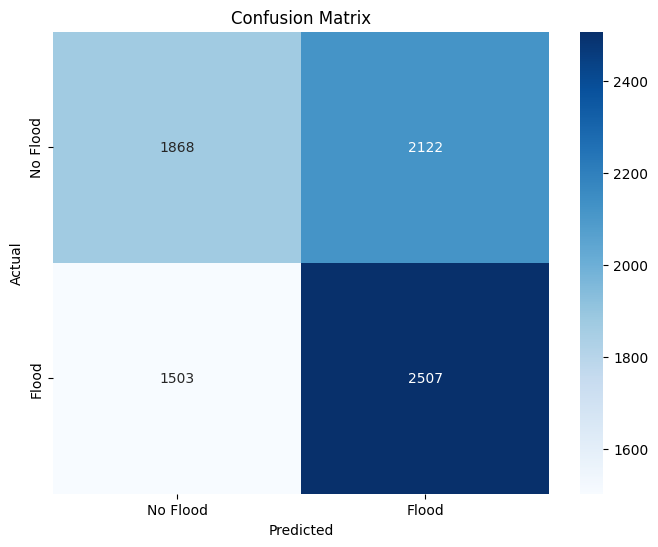

In [28]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Flood', 'Flood'],
            yticklabels=['No Flood', 'Flood'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [29]:
import xgboost as xgb

from sklearn.metrics import accuracy_score

xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss',max_depth = 5, reg_lambda = 1.5 , reg_alpha = 1)
xgb_model.fit(X_train, y_train)

probabilities = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (probabilities > 0.5).astype(int)

accuracy_xgb = accuracy_score(y_test, y_pred)

print(f"XGBoost Accuracy: {accuracy_xgb * 100:.2f}%")



c:\Users\Sachin Tripathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:02:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 82.53%


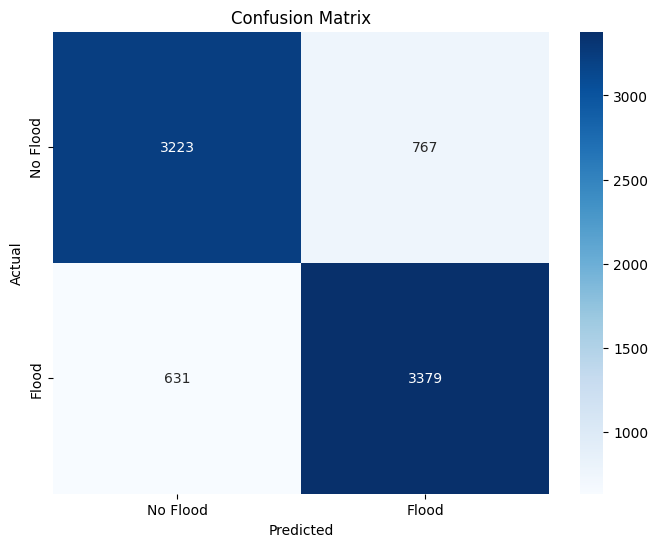

In [30]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Flood', 'Flood'],
            yticklabels=['No Flood', 'Flood'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [31]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score

lgb_model = lgb.LGBMClassifier(random_state=42,max_depth = 5, n_estimators = 100)
lgb_model.fit(X_train, y_train)

probabilities = lgb_model.predict_proba(X_test)[:, 1]

y_pred = (probabilities > 0.5).astype(int)

accuracy_lgb = accuracy_score(y_test, y_pred)
print(f"LightGBM Accuracy: {accuracy_lgb * 100:.2f}%")



[LightGBM] [Info] Number of positive: 16218, number of negative: 15782
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2309
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506812 -> initscore=0.027252
[LightGBM] [Info] Start training from score 0.027252
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

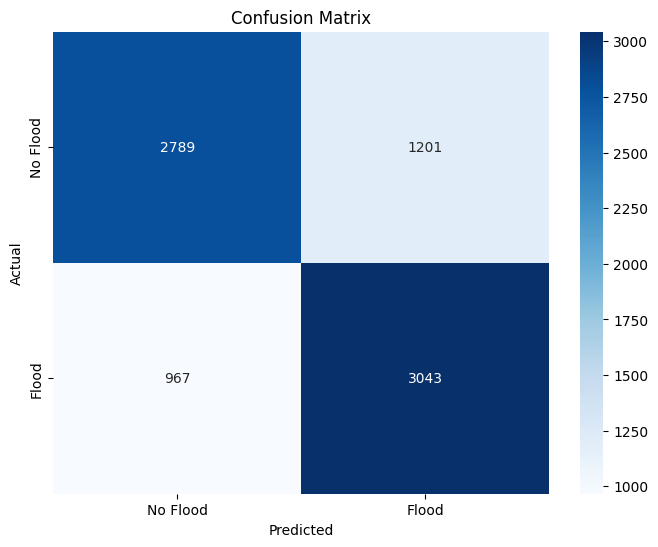

In [32]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Flood', 'Flood'],
            yticklabels=['No Flood', 'Flood'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

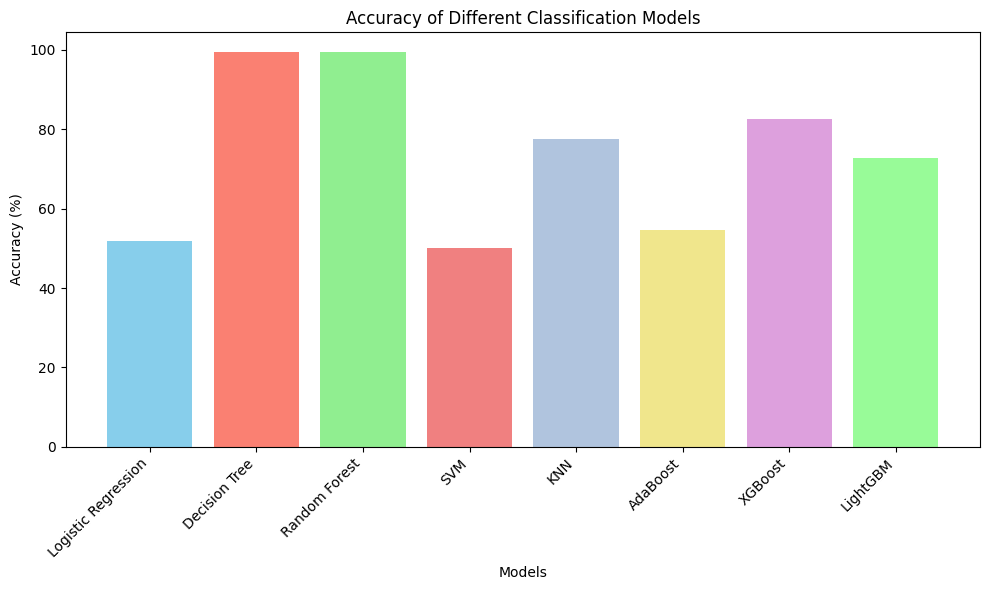

In [33]:
import matplotlib.pyplot as plt

accuracy_scores = [accuracy_lr, accuracy_dt, accuracy_rf, accuracy_svm, accuracy_knn, accuracy_adb, accuracy_xgb, accuracy_lgb]

accuracy_scores_percent = [score * 100 for score in accuracy_scores]

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN', 'AdaBoost', 'XGBoost', 'LightGBM']

plt.figure(figsize=(10, 6))
plt.bar(models, accuracy_scores_percent, color=['skyblue', 'salmon', 'lightgreen', 'lightcoral', 'lightsteelblue', 'khaki', 'plum', 'palegreen'])
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy of Different Classification Models")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [34]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(estimators=[
    ('Decision Tree', dt_model),
    ('Random Forest', rf_model),
    ('KNN', knn_model),
    ('XGBoost', xgb_model),
    ('LightGM',lgb_model),
], voting='soft', weights=[0.3,0.3,1,1,1])

voting_model.fit(X_train, y_train)

y_pred_voting = voting_model.predict(X_test)

accuracy_voting = accuracy_score(y_test, y_pred_voting)
print(f"Voting Classifier Accuracy: {accuracy_voting * 100:.2f}%")

c:\Users\Sachin Tripathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:02:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 16218, number of negative: 15782
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2309
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506812 -> initscore=0.027252
[LightGBM] [Info] Start training from score 0.027252
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

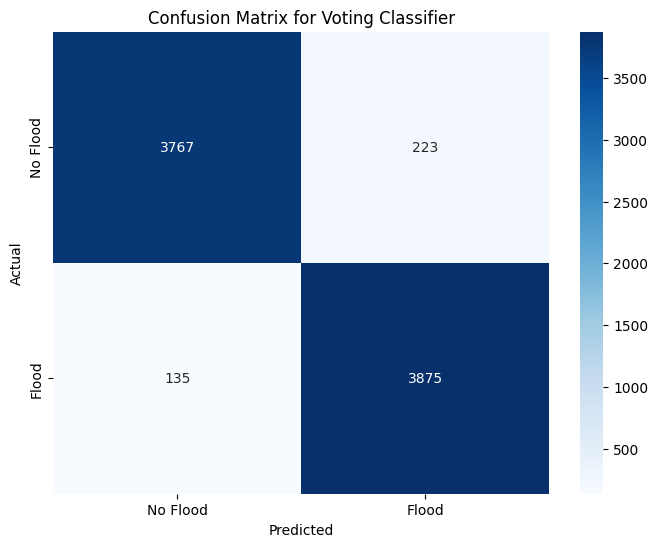

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_voting)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Flood', 'Flood'], yticklabels=['No Flood', 'Flood'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Voting Classifier')
plt.show()

In [36]:

Latitude = 19.04 #@param {type:"number"}
Longitude = 72.86 #@param {type:"number"}
Rainfall = 1000 #@param {type:"number"}
Temperature = 31 #@param {type:"number"}
Humidity = 30 #@param {type:"number"}
River_Discharge = 126.182888 #@param {type:"number"}
Water_Level = 4.415552 #@param {type:"number"}
Elevation = 15 #@param {type:"number"}
Land_Cover = 4 #@param {type:"number"} # assuming categorical data is pre-encoded
Soil_Type = 4 #@param {type:"number"} # assuming categorical data is pre-encoded
Population_Density = 15627 #@param {type:"number"}
Infrastructure = 0 #@param {type:"number"}
Historical_Floods = 0 #@param {type:"number"}

input_data = [
    Latitude, Longitude, Rainfall, Temperature, Humidity,
    River_Discharge, Water_Level, Elevation, Land_Cover,
    Soil_Type, Population_Density, Infrastructure, Historical_Floods
]

final_prediction = voting_model.predict([input_data])[0]

probabilities = voting_model.predict_proba([input_data])[0]

print("Final Prediction:", final_prediction)

if final_prediction == 0:
    print("Flood is not predicted to occur.")
else:
    print("Flood is predicted to occur.")


print(f"Probability of Flood: {probabilities[1] * 100:.2f}%")


Final Prediction: 0
Flood is not predicted to occur.
Probability of Flood: 32.30%


c:\Users\Sachin Tripathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Sachin Tripathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Sachin Tripathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\Sachin Tripathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Sachin Tripathi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn

In [47]:
import joblib

# Assuming 'model' is your trained model
joblib.dump(model, 'flood_model.pkl')

print("Flood model saved successfully!")


Flood model saved successfully!
